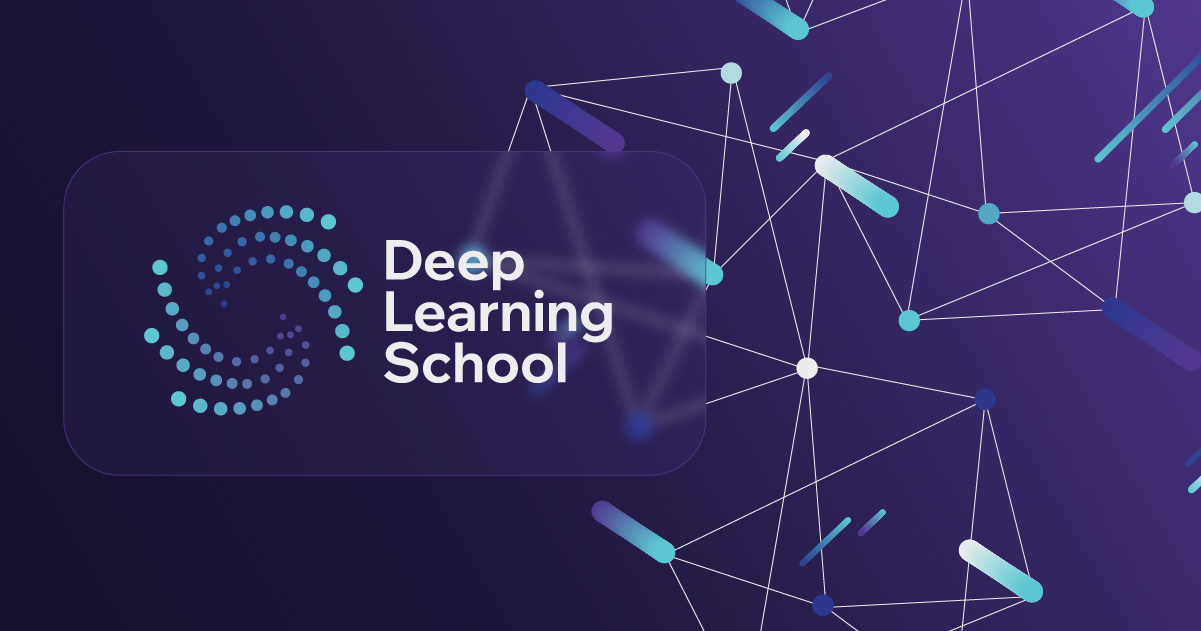


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [4]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import os
from tqdm import tqdm

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [12]:
# # Скачиваем картинки
# images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
# print("Path to dataset files:", images_path)

In [13]:
# # Скачиваем атрибуты
# attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
# print("Path to dataset files:", attrs_path)

In [11]:
    DATASET_PATH = "Data/DL1_DZ8/lfw-deepfunneled/lfw-deepfunneled"
    ATTRIBUTES_PATH = "Data/DL1_DZ8/lfw_attributes.txt"

In [14]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    if not os.path.exists(DATASET_PATH):
        print("Скачиваем изображения...")
        import kagglehub
        downloaded_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

        import shutil
        source_images = os.path.join(downloaded_path, "lfw-deepfunneled", "lfw-deepfunneled")
        if os.path.exists(source_images):
            os.makedirs(os.path.dirname(DATASET_PATH), exist_ok=True)
            shutil.copytree(source_images, DATASET_PATH, dirs_exist_ok=True)
            print(f"Изображения скопированы в {DATASET_PATH}")
    
    if not os.path.exists(ATTRIBUTES_PATH):
        print("Скачиваем атрибуты...")
        import kagglehub
        downloaded_attrs = kagglehub.dataset_download("averkij/lfw-attributes")
        source_attrs = os.path.join(downloaded_attrs, "lfw_attributes.txt")
        if os.path.exists(source_attrs):
            os.makedirs(os.path.dirname(ATTRIBUTES_PATH), exist_ok=True)
            shutil.copy2(source_attrs, ATTRIBUTES_PATH)
            print(f"Атрибуты скопированы в {ATTRIBUTES_PATH}")

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img: img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs


In [15]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания
images, attrs = fetch_dataset()
print(f"Загружено {len(images)} изображений")
print(f"Размер атрибутов: {attrs.shape}")

Скачиваем изображения...


100%|██████████████████████████████████| 112M/112M [00:10<00:00, 10.8MB/s]

Extracting files...


Изображения скопированы в Data/DL1_DZ8/lfw-deepfunneled/lfw-deepfunneled
Скачиваем атрибуты...


100%|████████████████████████████████| 6.49M/6.49M [00:01<00:00, 5.09MB/s]

Extracting files...


Атрибуты скопированы в Data/DL1_DZ8/lfw_attributes.txt
Загружено 13143 изображений
Размер атрибутов: (13143, 73)



Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [159]:
class DatasetImages(Dataset):
    def __init__(self, images, attrs, transform = None):
        self.images = images
        self.attrs = attrs.copy()
        self.transform = transform

        self.images = self.images.astype(np.float32) / 255.0

        if len(self.images.shape) == 3:  # [N, H, W]
            self.images = self.images[:, np.newaxis, :, :]  
        elif len(self.images.shape) == 4:  # [N, H, W, C]
            self.images = np.transpose(self.images, (0, 3, 1, 2))
        
        for col in self.attrs.columns:
            self.attrs[col] = pd.to_numeric(self.attrs[col], errors='coerce')

    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        image = self.images[idx]
        attrs = torch.tensor(self.attrs.iloc[idx].values, dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image)
        
        return image, attrs

In [160]:
faces_dataset = DatasetImages(images, attrs)
print(f"\nРазмер датасета: {len(faces_dataset)}")


Размер датасета: 13143


In [163]:
train_size = int(0.8 * len(faces_dataset))
val_size = len(faces_dataset) - train_size
train_dataset, val_dataset = random_split(faces_dataset, [train_size, val_size])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [168]:
def show_images(dataloader, num_images=None):
    batch = next(iter(dataloader))
    images, attrs = batch

    if num_images is None:
        num_images = images.size(0)
    else:
        num_images = min(num_images, images.size(0))

    images = torch.clamp(images, 0, 1)

    n_rows = (num_images + 2) // 3
    fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 4 * n_rows))

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx in range(num_images):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]

        img = images[idx]
        if img.shape[0] == 3: 
            img_display = img.permute(1, 2, 0).numpy()
        else: 
            img_display = img.squeeze().numpy()

        ax.imshow(img_display, cmap='gray' if img_display.ndim == 2 else None)
        ax.axis('off')

    total_subplots = n_rows * 3
    for idx in range(num_images, total_subplots):
        row = idx // 3
        col = idx % 3
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

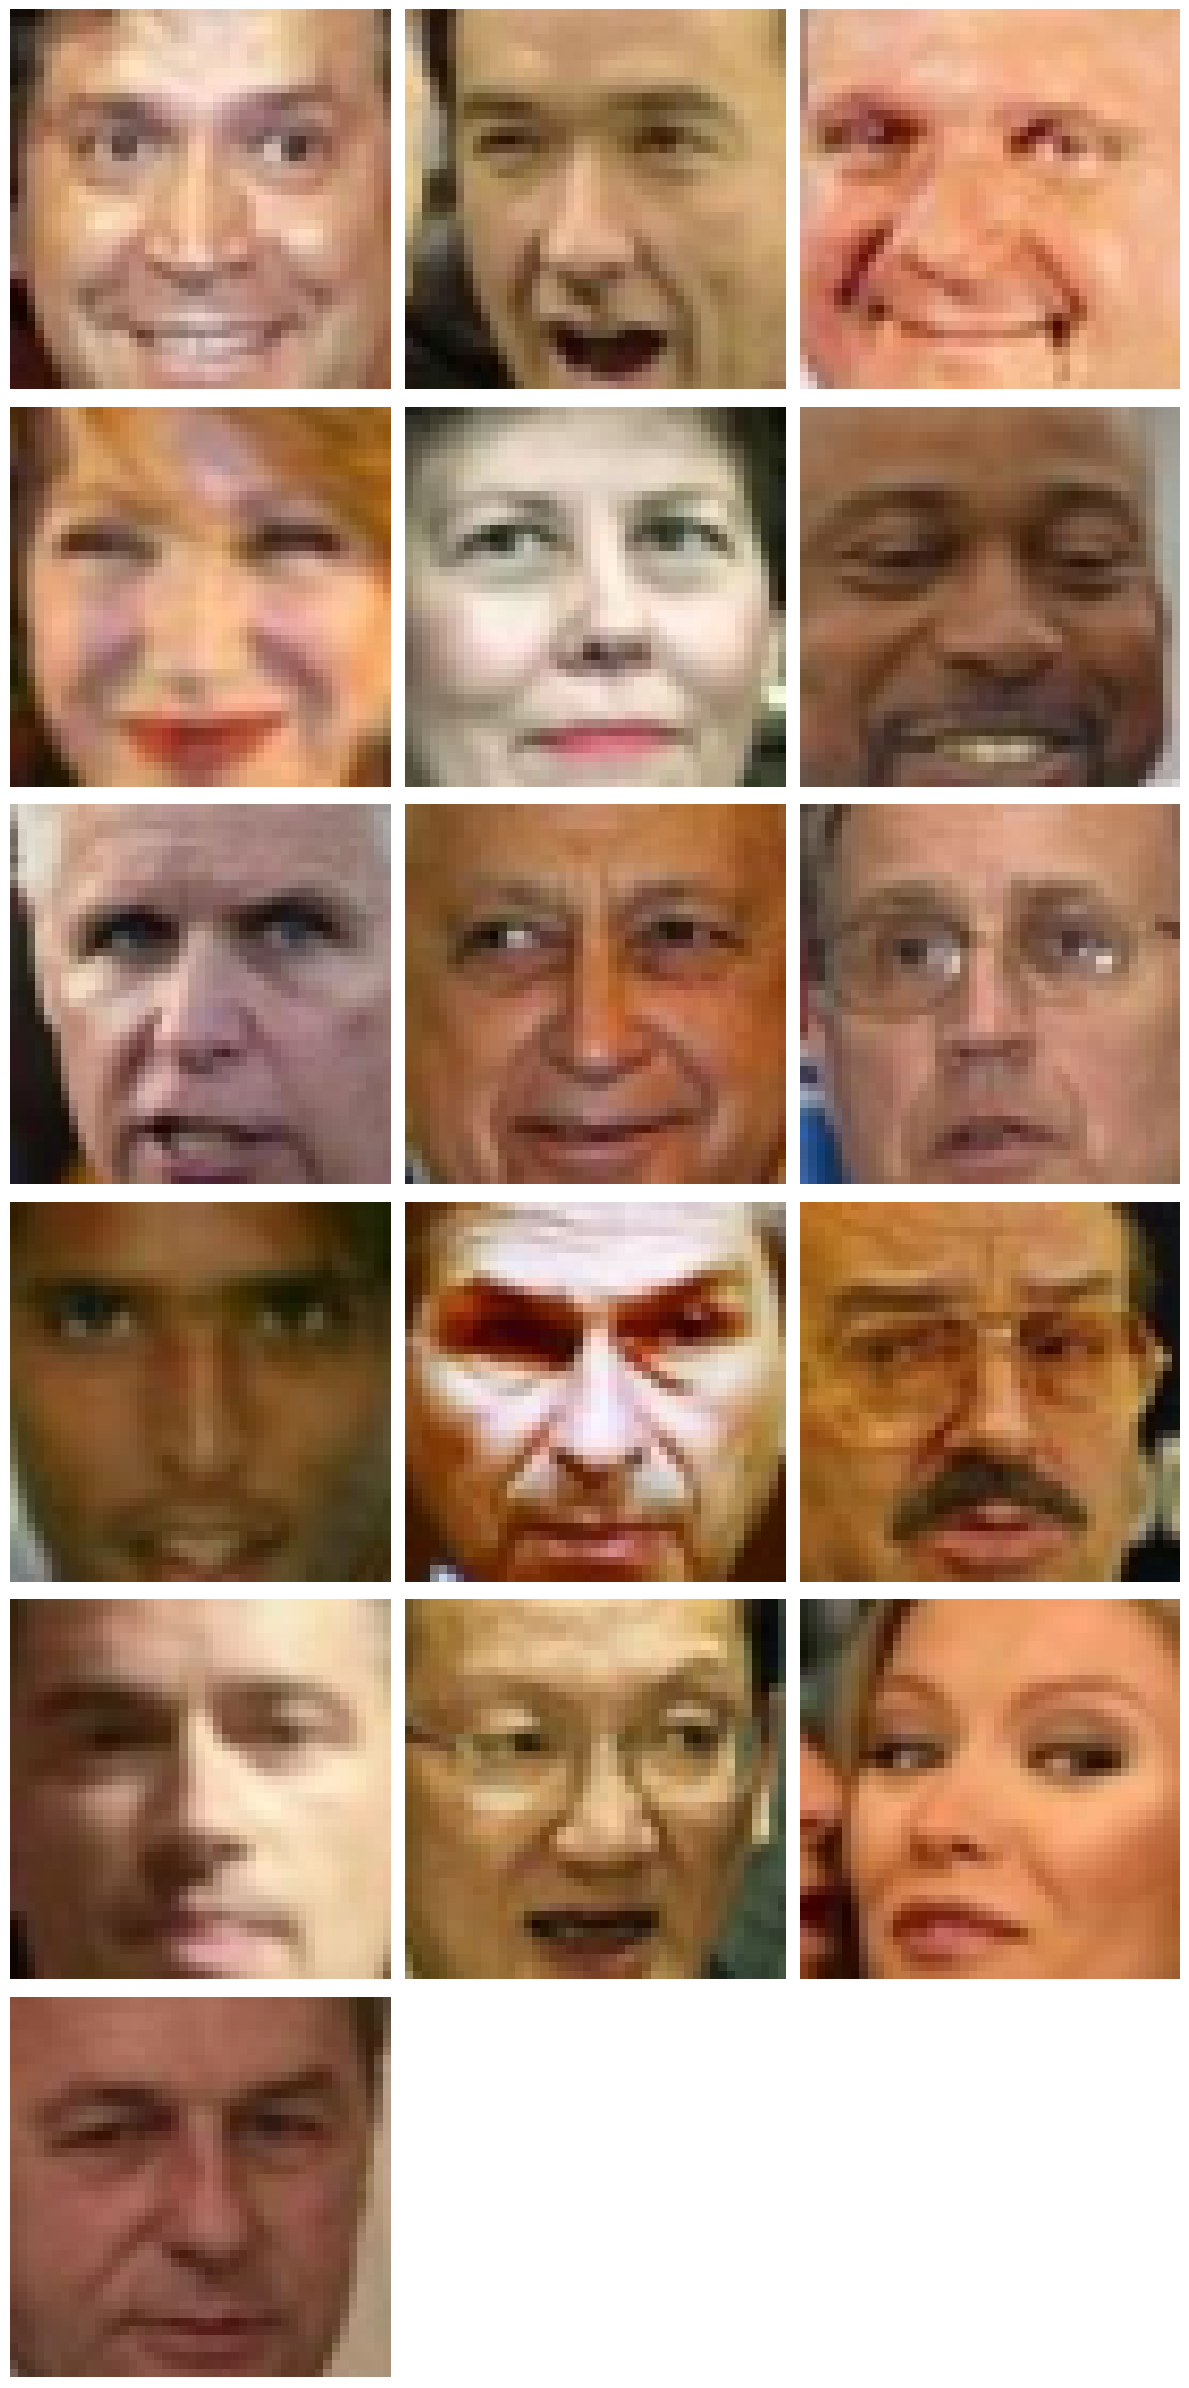

In [170]:
show_images(val_loader)

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



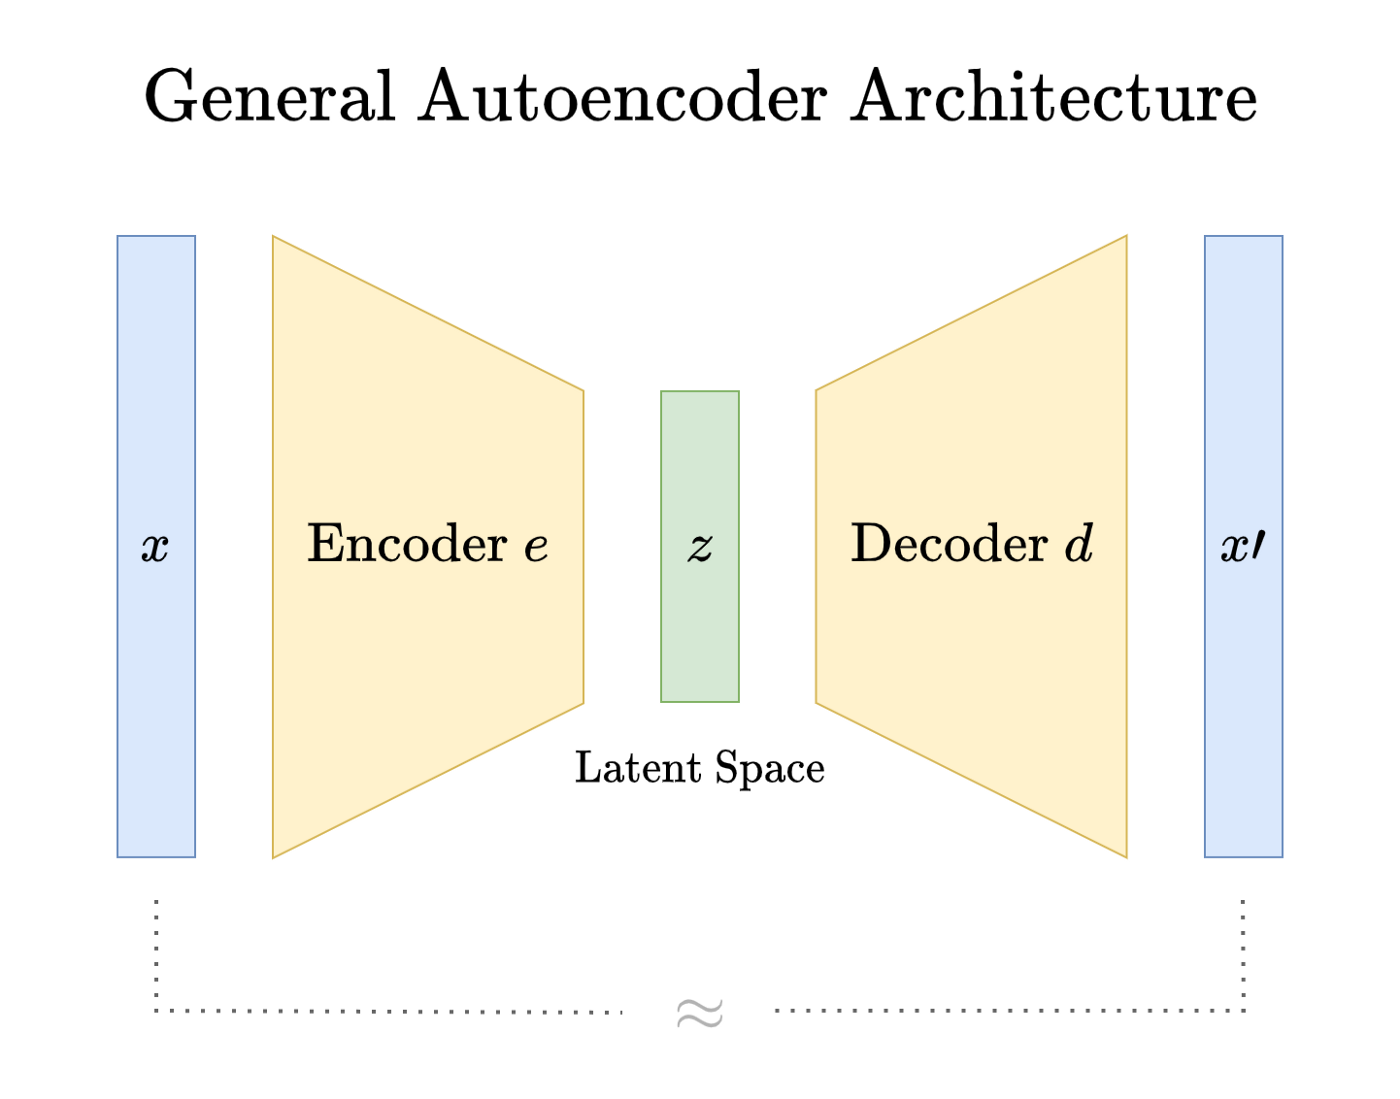

In [108]:
for batch in train_loader:
    print(batch[0].shape)       
    print(batch[0].shape[2:])     
    break

torch.Size([16, 45, 45, 3])
torch.Size([45, 3])


In [113]:
dim_code = 64

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [194]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(Autoencoder, self).__init__()
        input_size = 3 * 45 * 45

        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_size),
            nn.Sigmoid()  
        )

    def sample(self, vector):
        reconstruction = self.decoder(vector)
        return reconstruction

    def forward(self, x):
        batch_size = x.shape[0]
        x_flat = x.view(batch_size, -1)

        latent = self.encoder(x_flat)
        reconstruction_flat = self.decoder(latent)
        reconstruction = reconstruction_flat.view(batch_size, 3, 45, 45)
        
        return reconstruction, latent

In [172]:
criterion = F.mse_loss

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [280]:
datapath = 'Data/DL1_DZ8/'
%matplotlib inline


In [321]:
class TrainingModel:
    def __init__(self, model, criterion, optimizer = None, model_name='Noname_model', 
                 is_vae = False, is_cvae = False):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = model.to(self.device)
        self.criterion = criterion 
        self.optimizer = optimizer if optimizer !=None else torch.optim.Adam(params=self.model.parameters(), lr = 1e-3)
        self.path = datapath+model_name+'/'
        self.is_vae = is_vae
        self.is_cvae = is_cvae
        os.makedirs(self.path, exist_ok=True)
        
    def train_one_epoch(self):
        device = self.device
        self.model.train()
        total_loss = 0
        
        for batch in self.train_dataloader:
            images = batch[0] 
            images = images.to(device)
            
            if self.is_cvae:
                labels = batch[1].to(device)
                class_num = torch.eye(10).to(self.device)[labels]
                mu, logsigma, reconstruction = self.model(images, class_num)
                loss = loss_vae(images, mu, logsigma, reconstruction)
            elif self.is_vae:
                mu, logsigma, reconstruction = self.model(images)
                loss = loss_vae(images, mu, logsigma, reconstruction)
            else:
                reconstructed, _ = self.model(images)
                loss = self.criterion(reconstructed, images)
            
            self.optimizer.zero_grad()   
            loss.backward()       
            self.optimizer.step()     
    
            total_loss += loss.item()
 
        avg_loss = total_loss / len(self.train_dataloader)
        return avg_loss

    def eval_one_epoch(self):
        val_dataloader = self.val_dataloader
        device = self.device
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in self.val_dataloader:
                images = batch[0] 
                images = images.to(device)

                if self.is_cvae:
                    labels = batch[1].to(device)
                    class_num = torch.eye(10).to(self.device)[labels]
                    mu, logsigma, reconstruction = self.model(images, class_num)
                    loss = loss_vae(images, mu, logsigma, reconstruction)
                elif self.is_vae:
                    mu, logsigma, reconstruction = self.model(images)
                    loss = loss_vae(images, mu, logsigma, reconstruction)
                else:
                    reconstructed, _ = self.model(images)
                    loss = self.criterion(reconstructed, images)

                total_loss += loss.item()
 
        avg_loss = total_loss / len(self.val_dataloader)
        return avg_loss
       
    def train_model(self, num_epoch, patience = 10,
                    train_dataloader = train_loader, val_dataloader = val_loader, 
                    show_images = True, show_loss = True):
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.train_losses = []
        self.eval_losses = []
        best_model_state = self.model.state_dict().copy()
        epochs_without_improvement = 0
        best_eval_loss = float('inf')
        
        for epoch in tqdm(range(num_epoch), total = num_epoch):
            train_loss = self.train_one_epoch()
            self.train_losses.append(train_loss)
            eval_loss = self.eval_one_epoch()
            self.eval_losses.append(eval_loss)
            
            if eval_loss < best_eval_loss:
                best_eval_loss = eval_loss
                epochs_without_improvement = 0
                best_model_state = self.model.state_dict().copy()
                torch.save(best_model_state, f'{self.path}best_model.pth')   
            else:
                epochs_without_improvement+=1
                
            if (epoch+1)%10 == 0:
                if show_images:  
                    self.show_images()
                if show_loss: 
                    self.show_plot()
                
            if epochs_without_improvement>=patience:
                break

        self.model.load_state_dict(best_model_state)
        torch.save(best_model_state, f'{self.path}final_best_model.pth')      

    def show_images(self):
        batch = next(iter(self.val_dataloader))
        images = batch[0][:6].to(self.device)
    
        with torch.no_grad():
            if self.is_cvae:
                labels = batch[1][:6].to(device)
                class_num = torch.eye(10).to(self.device)[labels]
                _, _, reconstructed_images = self.model(images, class_num)
            elif self.is_vae:
                _, _, reconstructed_images = self.model(images)
            else:
                reconstructed_images, _ = self.model(images)
        
        reconstructed_images = reconstructed_images.cpu()
    
        fig, axes = plt.subplots(2, 3, figsize=(10, 6))
        axes = axes.ravel()
    
        for i in range(6):
            if self.is_vae:
                img_display = reconstructed_images[i].view(28, 28).numpy() 
            else:
                img_display = reconstructed_images[i].permute(1, 2, 0).numpy()

            if img_display.max() > 1.0:
                img_display = img_display / img_display.max()
    
            axes[i].imshow(img_display, cmap='gray' if img_display.ndim == 2 else None)
            axes[i].set_title(f'Image {i+1}')
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    plt.tight_layout()
    plt.show()

    def show_plot(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.eval_losses, label='Validation Loss') 
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()  
        plt.grid(True, alpha=0.3) 
        plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [208]:
autoencoder = TrainingModel(model = Autoencoder(), criterion=criterion)

 30%|███████████▍                          | 9/30 [00:35<01:22,  3.91s/it]

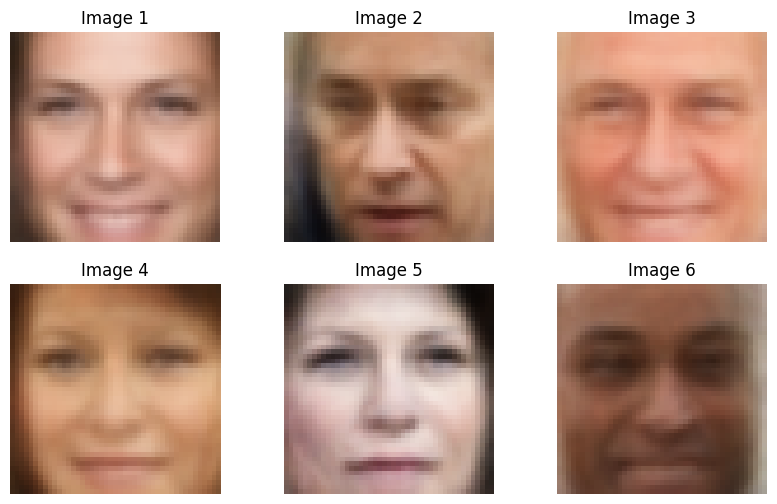

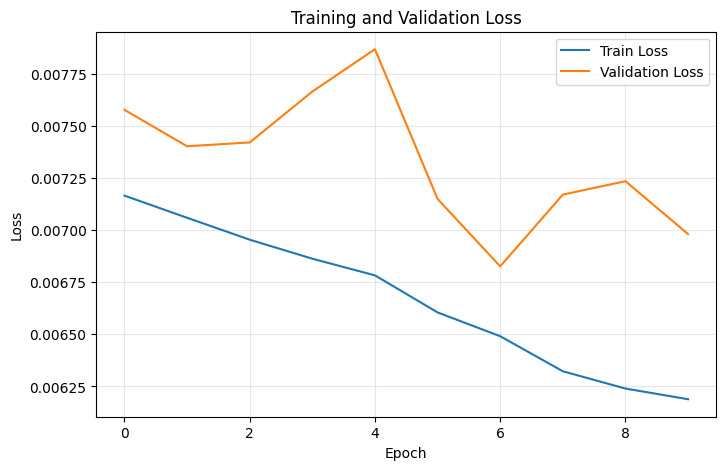

 63%|███████████████████████▍             | 19/30 [01:14<00:43,  3.96s/it]

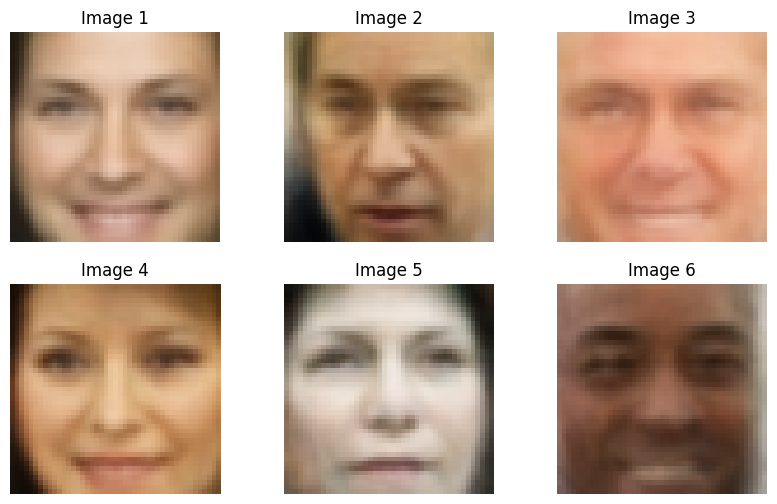

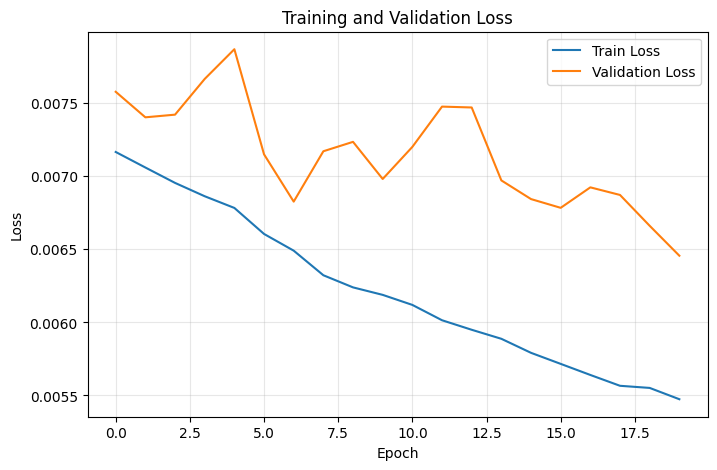

 97%|███████████████████████████████████▊ | 29/30 [01:54<00:03,  3.92s/it]

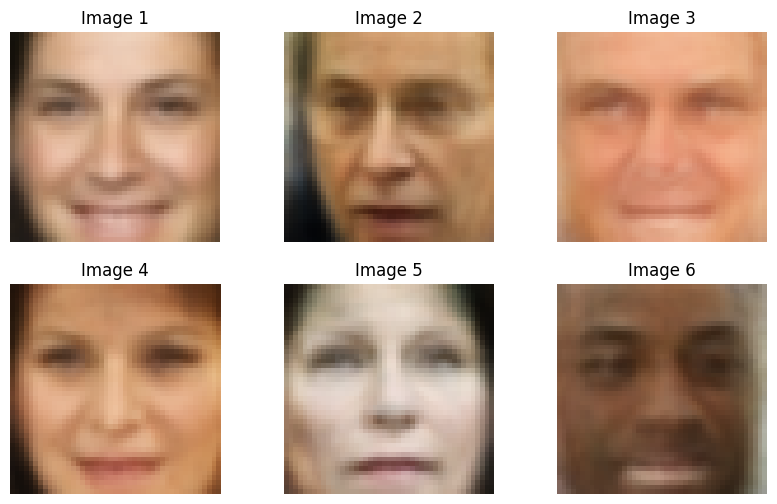

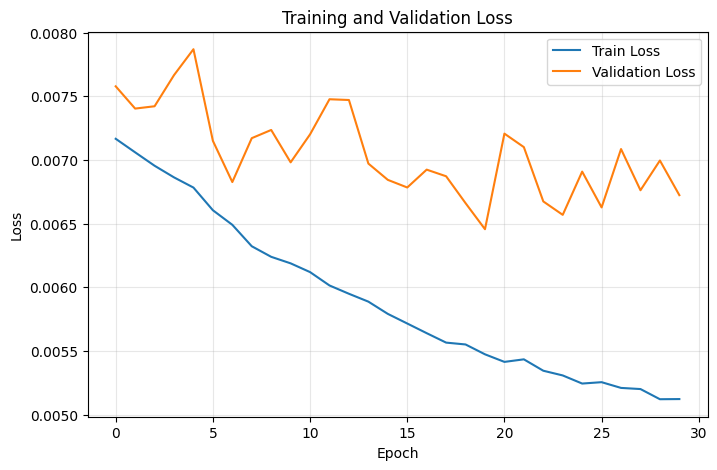

 97%|███████████████████████████████████▊ | 29/30 [01:58<00:04,  4.10s/it]


In [215]:
autoencoder.train_model(num_epoch=30, show_images = True, show_loss=True)

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

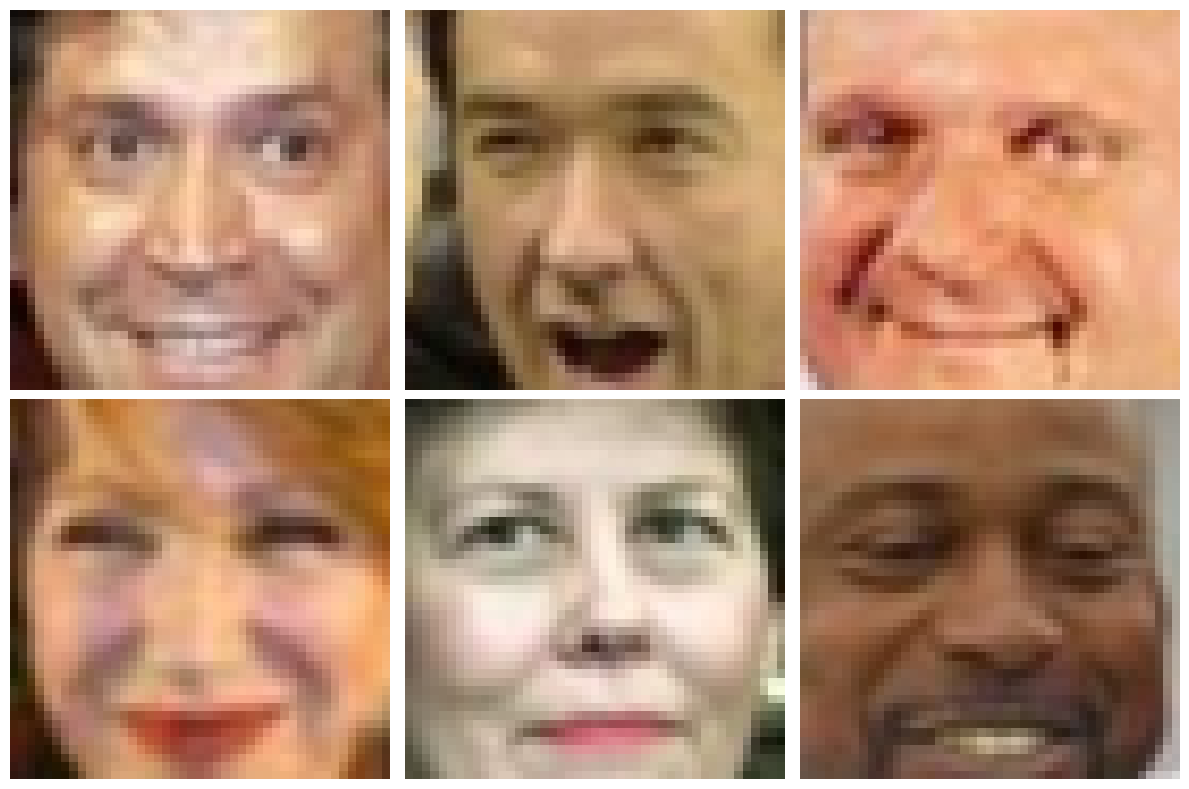

In [212]:
show_images(val_loader, 6) #Это оригинальные

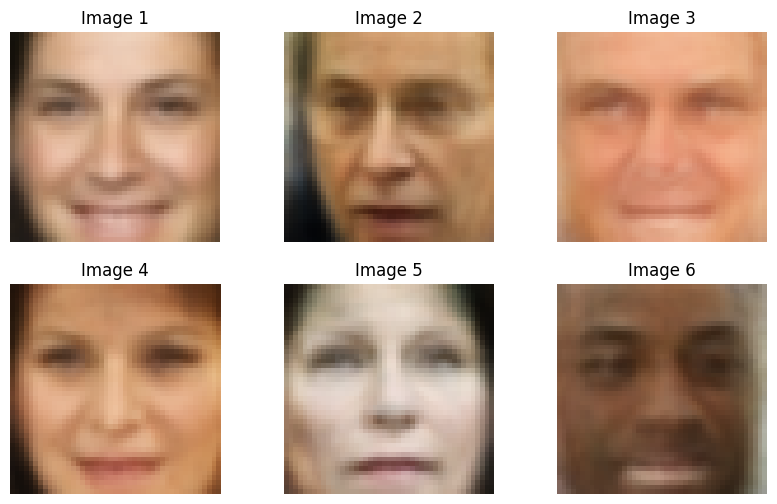

In [217]:
autoencoder.show_images() #Это восстановленные

Что вы можете сказать про результат?

Ну, он явно уловил цвет кожи, факт улыбки, общие какие-то черты лица. Некоторые лица вполне похожи. Учить его 50 эпох (10, 10 и потом 30) не стоило, кажется, он переобучился примерно на 25 эпохе, но к счастью, загрузил лучшее состояние, так что всё в порядке

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [ ]:
# сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, 64)
output = <скормите z декодеру>
<выведите тут полученные картинки>

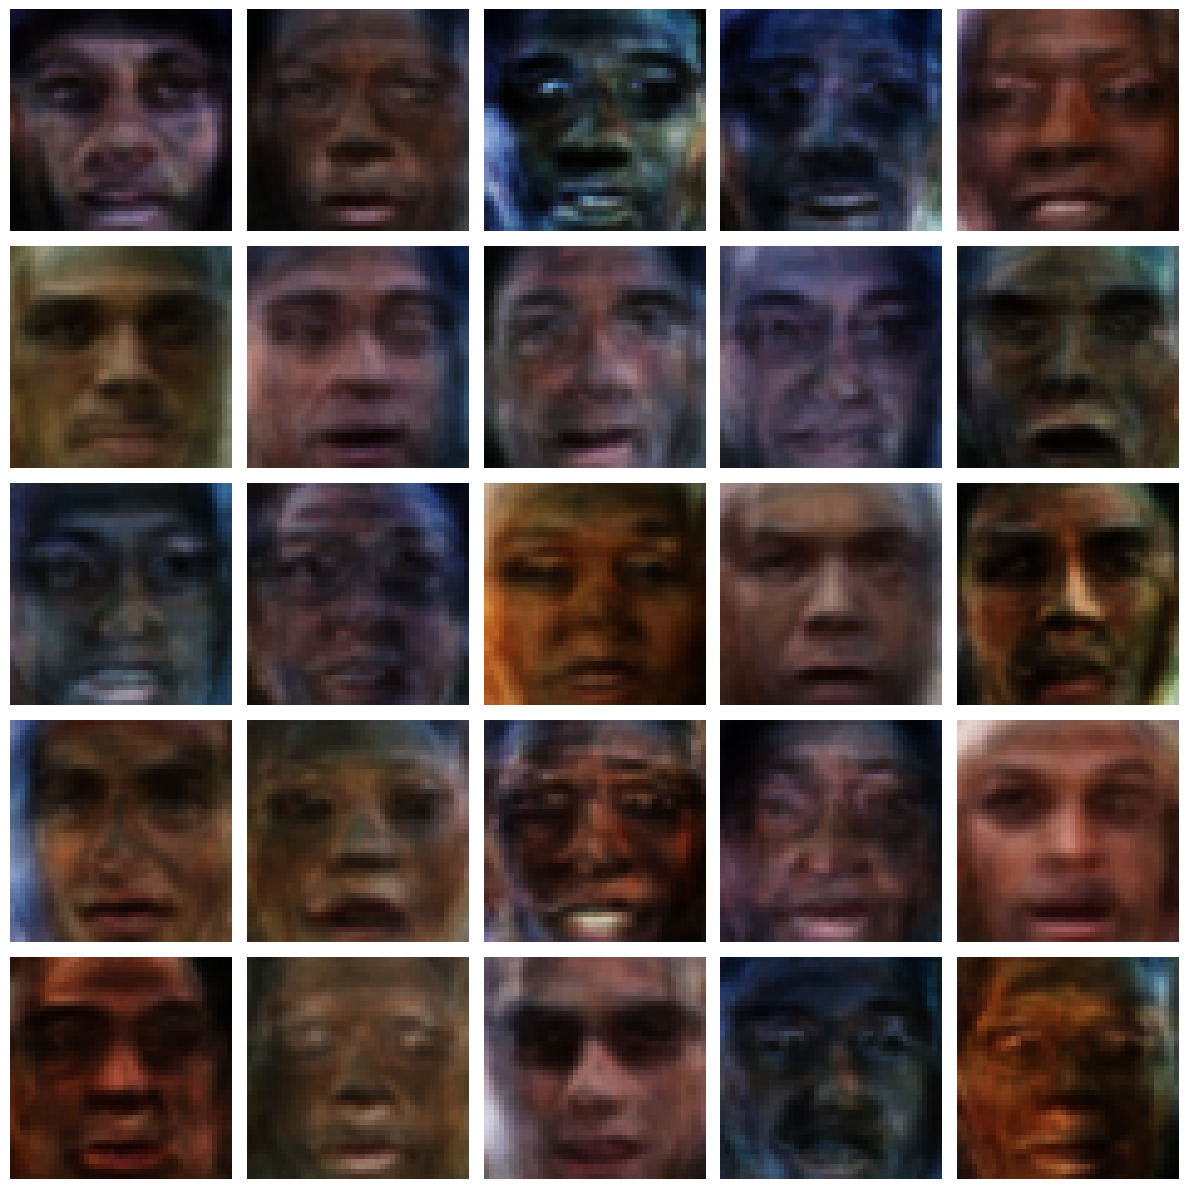

In [224]:
autoencoder.model.eval()
sample_images = train_dataset[:100][0]
sample_images = sample_images.to(autoencoder.device)
sample_images = sample_images.reshape(sample_images.shape[0], -1)

with torch.no_grad():
    latent_vectors = autoencoder.model.encoder(sample_images)

mean_latent = latent_vectors.mean().item()
std_latent = latent_vectors.std().item()

z = np.random.randn(25, 64) * std_latent + mean_latent
z_tensor = torch.FloatTensor(z).to(autoencoder.device)

with torch.no_grad():
    output_flat = autoencoder.model.decoder(z_tensor)

output_images = output_flat.view(25, 3, 45, 45)

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axes.flatten()):
    img = output_images[i].cpu().numpy().transpose(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#Ну, в целом, это похоже на лица. На всех изображениях можно обнаружить
# и глаза, и нос, и рот. А некоторая жутковатость вполне простительна

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [225]:
attrs_df = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)
attrs_df = pd.DataFrame(attrs_df.iloc[:, :-1].values, columns=attrs_df.columns[1:])

print(attrs_df.columns.tolist())

['person', 'imagenum', 'Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth', 'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair', 'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling', 'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash', 'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair', 'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead', 'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows', 'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose', 'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open', 'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee', 'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face', 'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man', 'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes', 'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pale Skin', "5 o' Clock Shadow", 'Strong Nose-Mouth Lines', 'Wearing Lipstick

In [244]:
smiling_attr = 'Smiling'
smiling_indices = attrs_df[attrs_df[smiling_attr] > 0.5].index[:15].tolist()
non_smiling_indices = attrs_df[attrs_df[smiling_attr] <0.5].index[:15].tolist()

print(f"{len(smiling_indices)} улыбающихся и {len(non_smiling_indices)} грустных")

15 улыбающихся и 15 грустных


In [233]:
autoencoder.model.eval()

smiling_latents = []
non_smiling_latents = []

with torch.no_grad():
    for idx in smiling_indices:
        img = torch.FloatTensor(images[idx]).unsqueeze(0) / 255.0
        if len(img.shape) == 3:
            img = img.unsqueeze(0)
        img = img.to(autoencoder.device)
        
        _, latent = autoencoder.model(img)
        smiling_latents.append(latent.cpu().numpy())

    for idx in non_smiling_indices:
        img = torch.FloatTensor(images[idx]).unsqueeze(0) / 255.0
        if len(img.shape) == 3:
            img = img.unsqueeze(0)
        img = img.to(autoencoder.device)
        
        _, latent = autoencoder.model(img)
        non_smiling_latents.append(latent.cpu().numpy())

smiling_latents = np.vstack(smiling_latents)
non_smiling_latents = np.vstack(non_smiling_latents)

In [258]:
mean_smiling = np.mean(smiling_latents, axis=0)
mean_non_smiling = np.mean(non_smiling_latents, axis=0)

smile_vector = mean_smiling - mean_non_smiling

print(f"Размер вектора улыбки: {smile_vector.shape}")
print(f"Среднее значение вектора: {smile_vector.mean():.4f}")

Размер вектора улыбки: (64,)
Среднее значение вектора: -0.0050


In [255]:
non_smiling_indices_for_test = attrs_df[attrs_df[smiling_attr] <0.5].index[15:20].tolist()  
print(non_smiling_indices_for_test)

[23, 24, 25, 27, 28]


In [256]:
device = 'cuda'

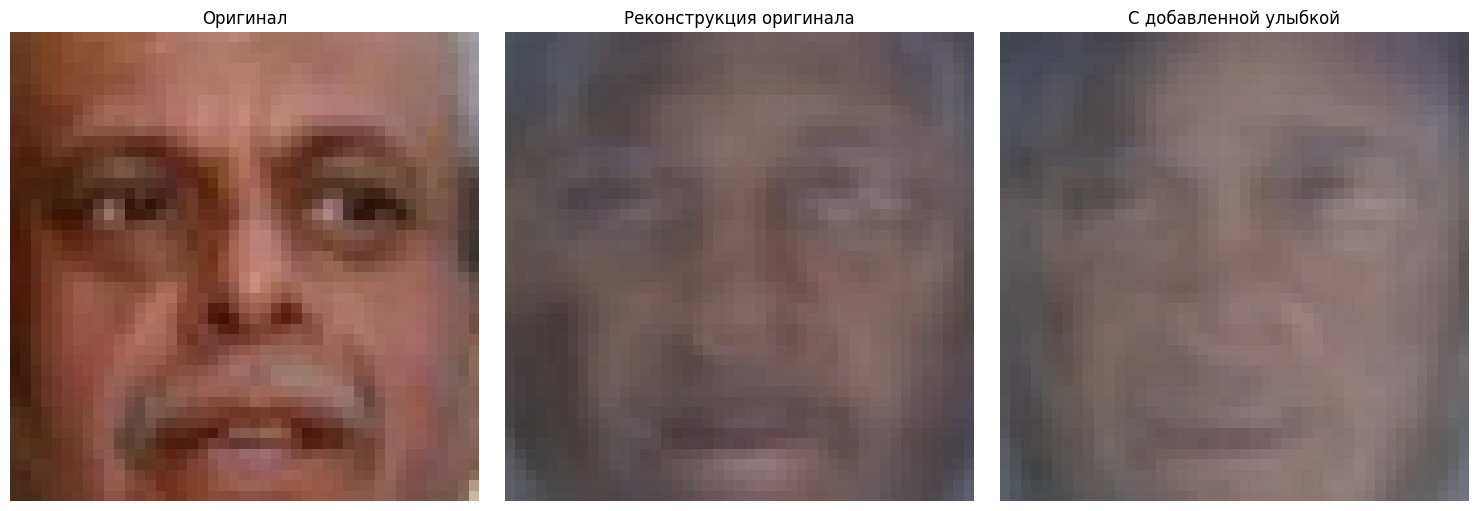

In [269]:
test_idx = 28
autoencoder.model.eval()

original_img = torch.FloatTensor(images[test_idx]).unsqueeze(0) / 255.0
if len(original_img.shape) == 3:
    original_img = original_img.unsqueeze(0)
original_img = original_img.to(device)
original_img_flat = original_img.view(1, -1)

with torch.no_grad():
    _, original_latent = autoencoder.model(original_img_flat)
    
    modified_latent = original_latent + torch.FloatTensor(smile_vector).to(device)
    
    reconstructed_original_flat = autoencoder.model.decoder(original_latent)
    reconstructed_smiling_flat = autoencoder.model.decoder(modified_latent)
    
    reconstructed_original = reconstructed_original_flat.view(1, 3, 45, 45)
    reconstructed_smiling = reconstructed_smiling_flat.view(1, 3, 45, 45)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(images[test_idx])
axes[0].set_title("Оригинал")
axes[0].axis('off')

axes[1].imshow(reconstructed_original.cpu().numpy().squeeze().transpose(1, 2, 0))
axes[1].set_title("Реконструкция оригинала")
axes[1].axis('off')

axes[2].imshow(reconstructed_smiling.cpu().numpy().squeeze().transpose(1, 2, 0))
axes[2].set_title("С добавленной улыбкой")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [272]:
batch_size = 32

# MNIST Dataset
train_dataset = datasets.MNIST(root=datapath, train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root=datapath, train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|████████████████████████████████| 9.91M/9.91M [00:02<00:00, 3.46MB/s]
100%|█████████████████████████████████| 28.9k/28.9k [00:00<00:00, 196kB/s]
100%|████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|████████████████████████████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [273]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)  
        self.fc_mu = nn.Linear(400, 20)  
        self.fc_logsigma = nn.Linear(400, 20)  

        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)
        
    def encode(self, x):
        x = x.view(-1, 784)  
        h = torch.relu(self.fc1(x)) 
        mu = self.fc_mu(h)  
        logsigma = self.fc_logsigma(h)  
        return mu, logsigma
    
    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(logsigma) 
            eps = torch.randn_like(sigma) 
            z = mu + eps * sigma 
            return z
        else:
            return mu  
    
    def decode(self, z):
        h = torch.relu(self.fc3(z))  
        reconstruction = torch.sigmoid(self.fc4(h))  
        return reconstruction
    
    def forward(self, x):
        mu, logsigma = self.encode(x)  
        z = self.gaussian_sampler(mu, logsigma)  
        reconstruction = self.decode(z) 
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [292]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений 
    разных людей
    """
    loss = -0.5 * torch.sum(1 + 2 * logsigma - mu.pow(2) - (2 * logsigma).exp())
    return loss
    return

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy(reconstruction, x.view(-1, 784), reduction='sum')
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    KL = KL_divergence(mu, logsigma)
    BCE = log_likelihood(x, reconstruction)
    return BCE + KL


И обучим модель:

In [289]:
criterion = loss_vae

autoencoder = TrainingModel(model = VAE(), criterion = criterion, is_vae = True, model_name = 'VAE')

 30%|███████████▍                          | 9/30 [01:07<02:36,  7.43s/it]

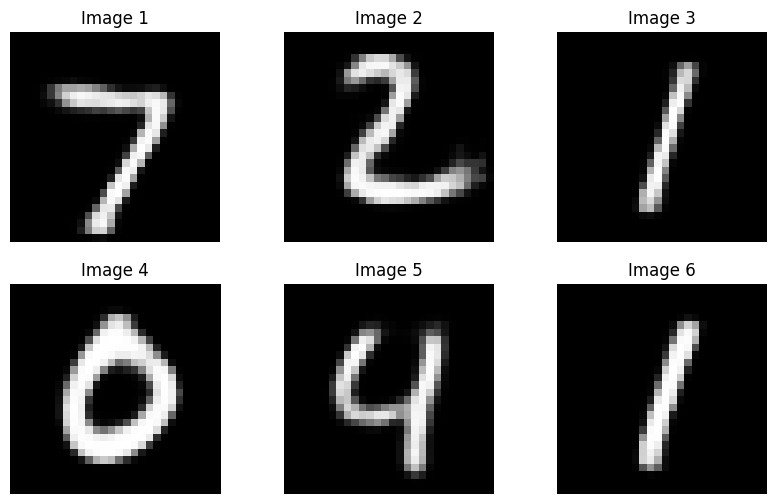

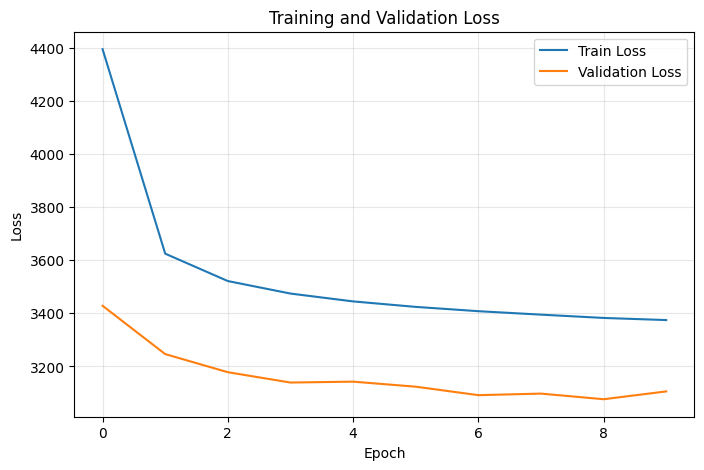

 63%|███████████████████████▍             | 19/30 [02:22<01:22,  7.46s/it]

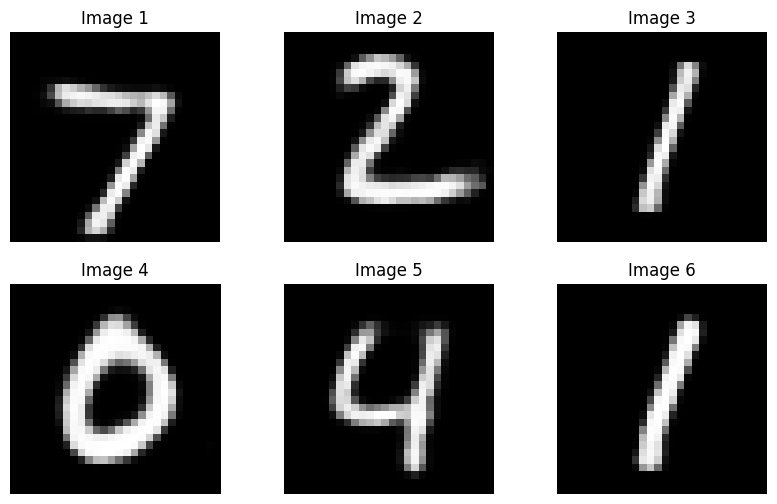

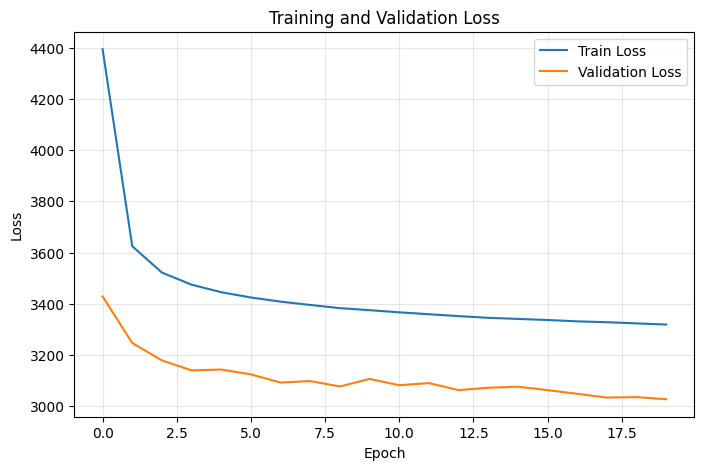

 97%|███████████████████████████████████▊ | 29/30 [03:37<00:07,  7.47s/it]

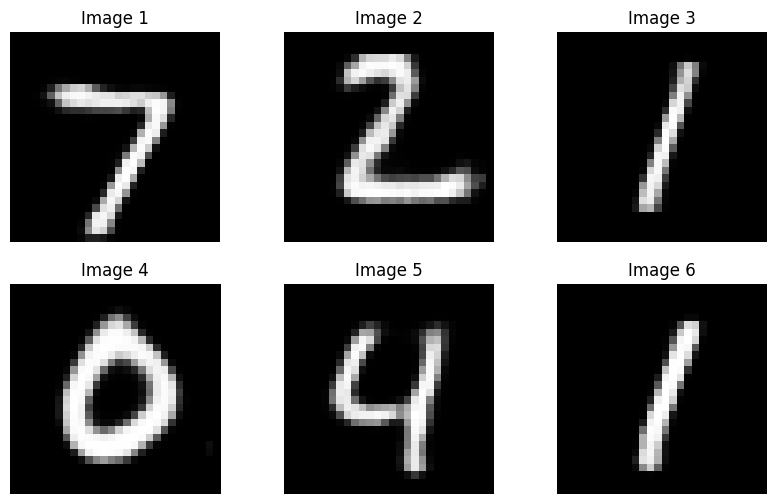

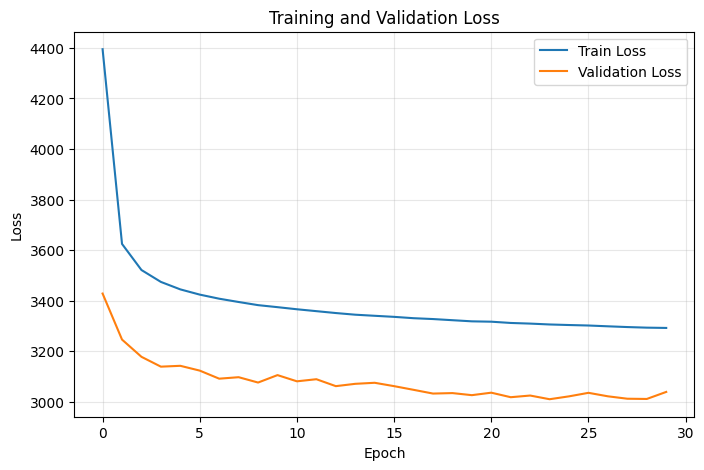

100%|█████████████████████████████████████| 30/30 [03:44<00:00,  7.49s/it]


In [293]:
autoencoder.train_model(num_epoch=30, train_dataloader=train_loader, val_dataloader = test_loader)

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

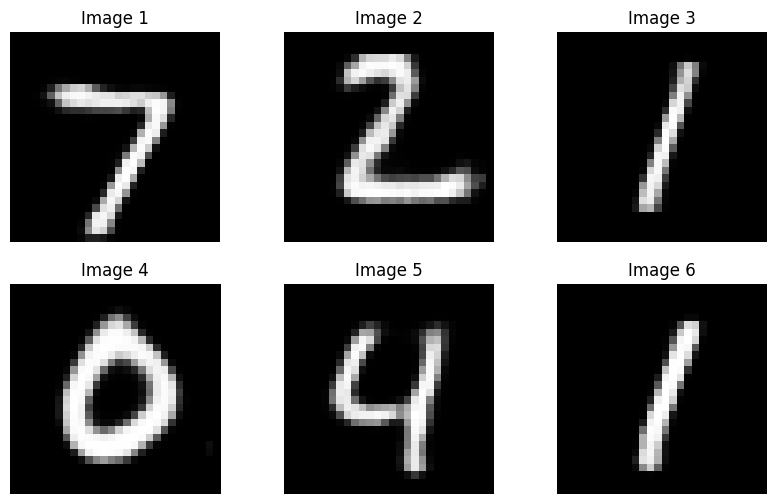

In [294]:
autoencoder.show_images()#Это восстановленные

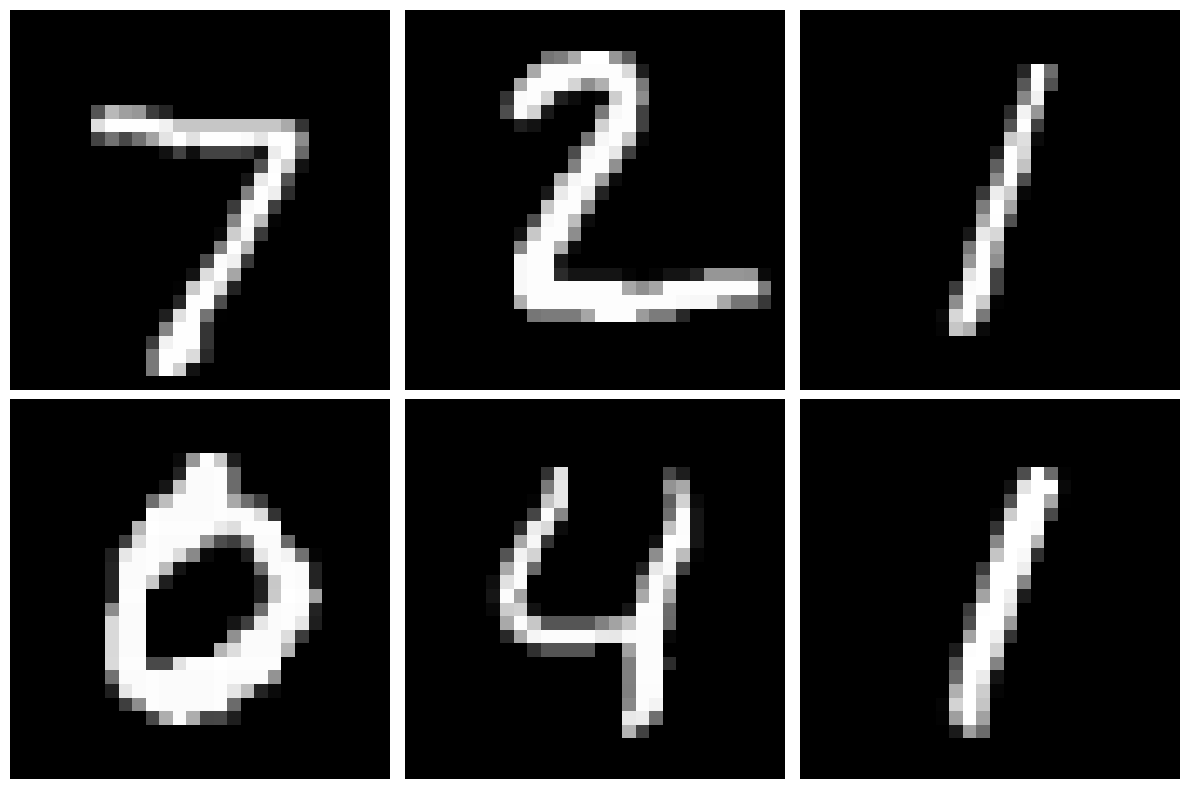

In [298]:
show_images(dataloader=test_loader, num_images=6 )#Вот это настоящие

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [301]:
autoencoder.model.eval()
all_mu = []

with torch.no_grad():
    for batch in train_loader:
        images = batch[0].to(device)
        mu, logsigma = autoencoder.model.encode(images)
        all_mu.append(mu.cpu().numpy())

all_mu = np.concatenate(all_mu, axis=0)

mu_mean = all_mu.mean(axis=0)
mu_std = all_mu.std(axis=0)

print("Средние по компонентам:", mu_mean[:5])  
print("Стандартные отклонения:", mu_std[:5])

Средние по компонентам: [ 0.06549003 -0.05163879  0.09807552  0.11059414  0.08250959]
Стандартные отклонения: [0.92891604 0.9302934  0.96816695 0.8892575  0.9037598 ]


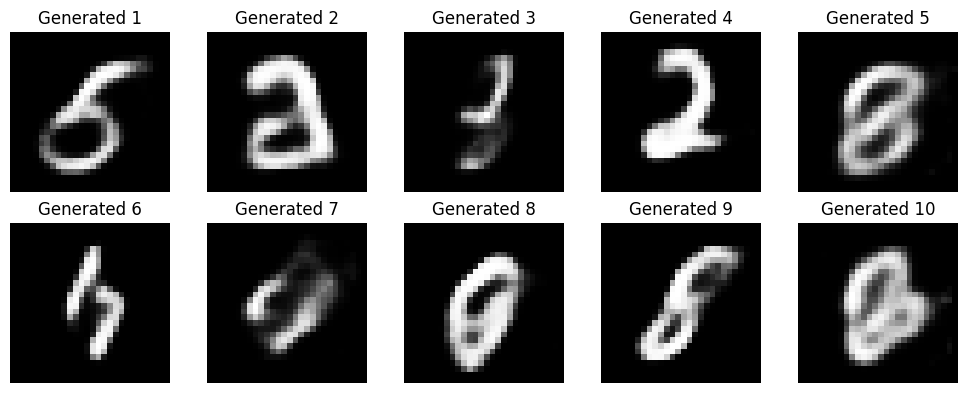

In [302]:
z = np.random.normal(mu_mean, mu_std, (10, 20))
z = torch.FloatTensor(z).to(device)

autoencoder.model.eval()
with torch.no_grad():
    generated_images = autoencoder.model.decode(z)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    img = generated_images[i].cpu().view(28, 28).numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Generated {i+1}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

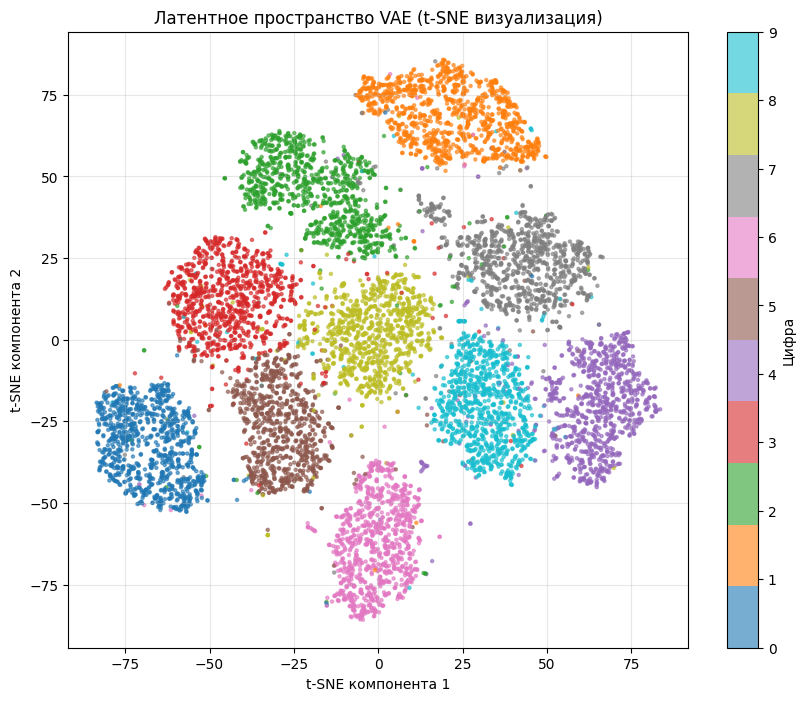

In [304]:
from sklearn.manifold import TSNE

autoencoder.model.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for batch in test_loader:
        images = batch[0].to(device)
        true_labels = batch[1] 
        
        mu, _ = autoencoder.model.encode(images) 
        latent_vectors.append(mu.cpu().numpy())
        labels.append(true_labels.numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)

tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], 
                      c=labels,    
                      cmap='tab10',     
                      alpha=0.6,        
                      s=5)            

plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('Латентное пространство VAE (t-SNE визуализация)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(True, alpha=0.3)
plt.show()

Что вы думаете о виде латентного представления?

Мне очень нравится это красивое латентное распределение. Все классы красиво различаются, красиво группируются пятнышками, и вообще, очень миловидны. Мне показалось необычным, что 0 сгруппировались рядом с 5 и 3. Было бы более ожидаемо, если бы рядом с 9 или 8. Но вот то что 4 и 7 рядом, 1 и 7 рядом - это логично и ожидаемо.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [305]:
class CVAE(nn.Module):
    def __init__(self):
        super(CVAE, self).__init__()

        self.fc1 = nn.Linear(784 + 10, 400)
        self.fc_mu = nn.Linear(400, 20)
        self.fc_logsigma = nn.Linear(400, 20)

        self.fc3 = nn.Linear(20 + 10, 400)
        self.fc4 = nn.Linear(400, 784)
        
    def encode(self, x, class_num):
        x = x.view(-1, 784)  
        x = torch.cat([x, class_num], dim=1)
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma, class_num
    
    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(logsigma)
            eps = torch.randn_like(sigma)
            z = mu + eps * sigma
            return z
        else:
            return mu
    
    def decode(self, z, class_num):
        z = torch.cat([z, class_num], dim=1)
        h = torch.relu(self.fc3(z))
        reconstruction = torch.sigmoid(self.fc4(h))
        return reconstruction
    
    def forward(self, x, class_num):
        mu, logsigma, _ = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, class_num)
        return mu, logsigma, reconstruction

In [322]:
cvae_model = CVAE()
optimizer = torch.optim.Adam(params=cvae_model.parameters(), lr=1e-3)
cvae_trainer = TrainingModel(cvae_model, criterion = criterion, optimizer=optimizer, 
                             is_vae=True, is_cvae=True, model_name='my_CVAE')

 30%|███████████▍                          | 9/30 [01:10<02:44,  7.82s/it]

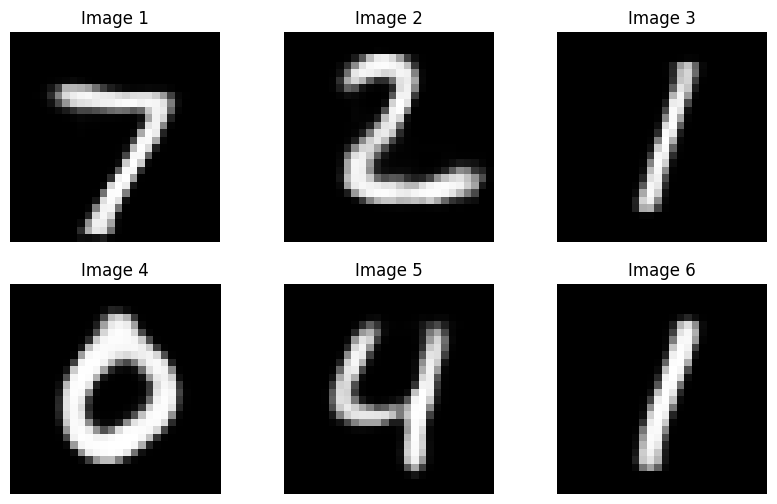

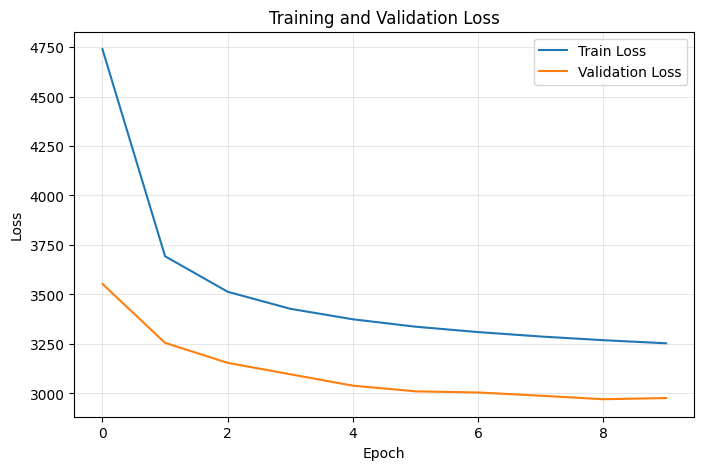

 63%|███████████████████████▍             | 19/30 [02:28<01:26,  7.84s/it]

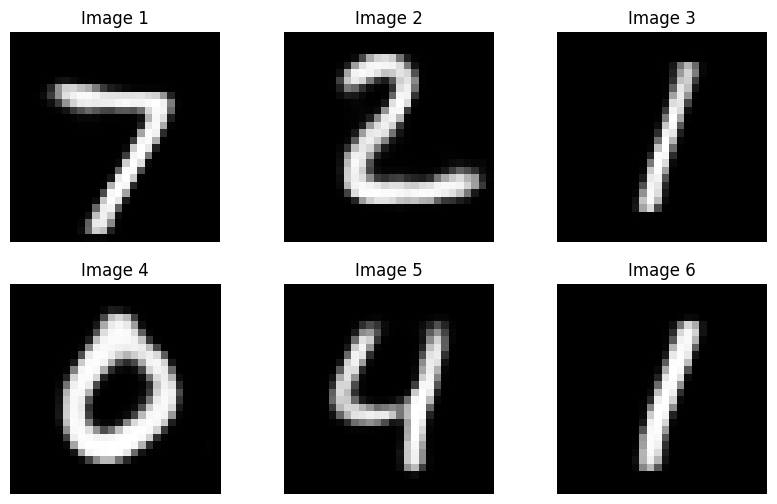

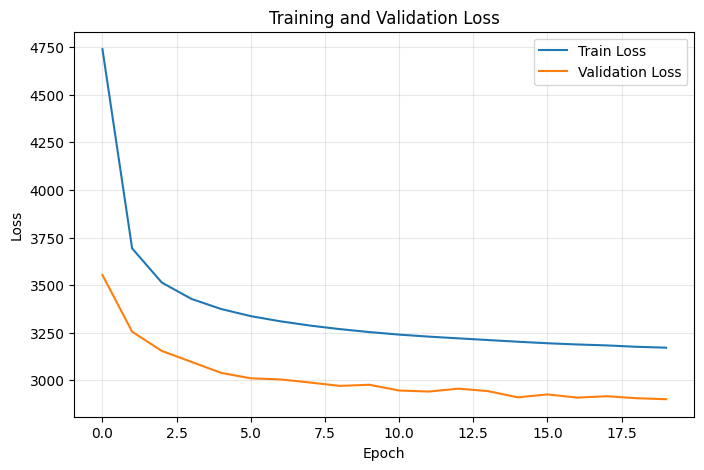

 97%|███████████████████████████████████▊ | 29/30 [03:47<00:07,  7.84s/it]

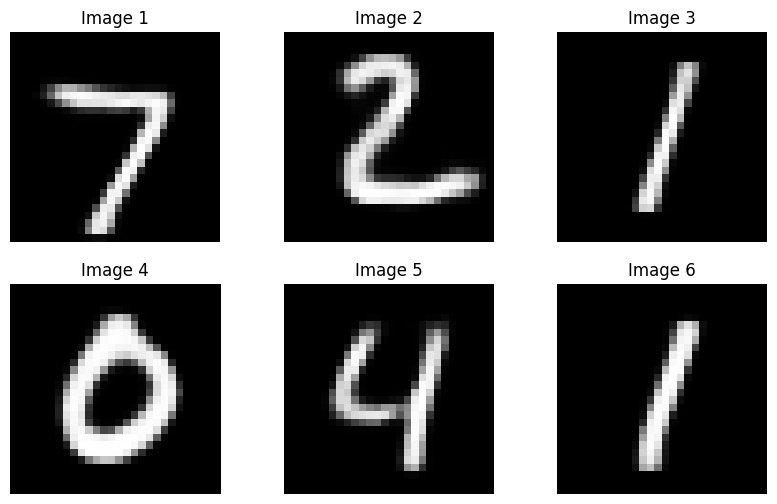

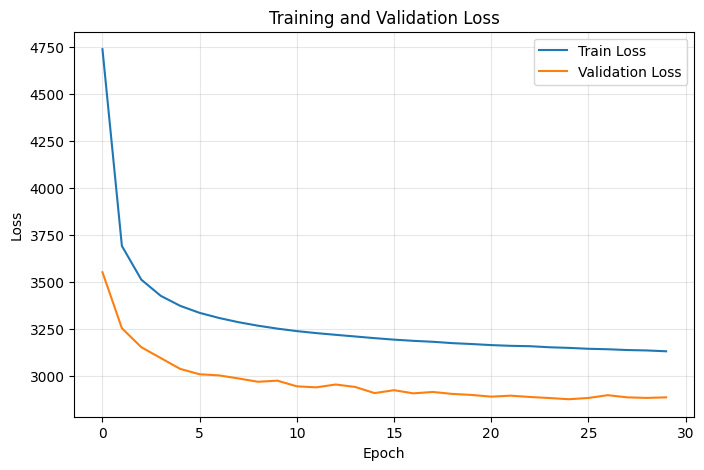

100%|█████████████████████████████████████| 30/30 [03:55<00:00,  7.84s/it]


In [323]:
cvae_trainer.train_model(num_epoch=30, patience=30,  
                         train_dataloader=train_loader,
                         val_dataloader=test_loader,
                         show_images=True, show_loss=True)

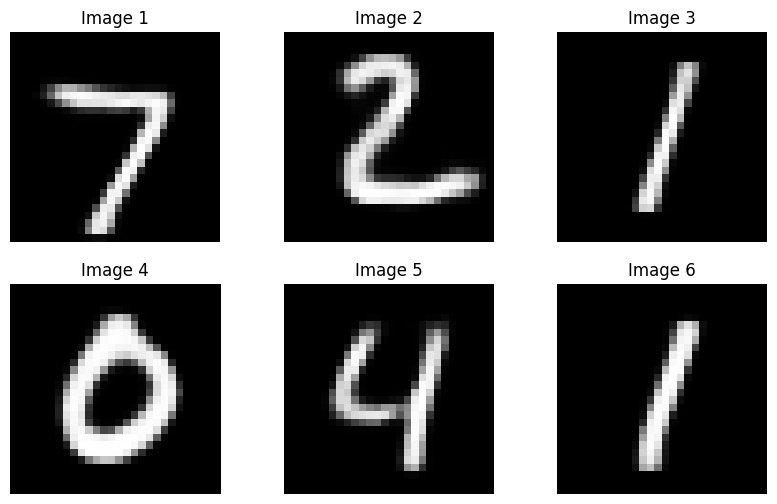

In [324]:
cvae_trainer.show_images()

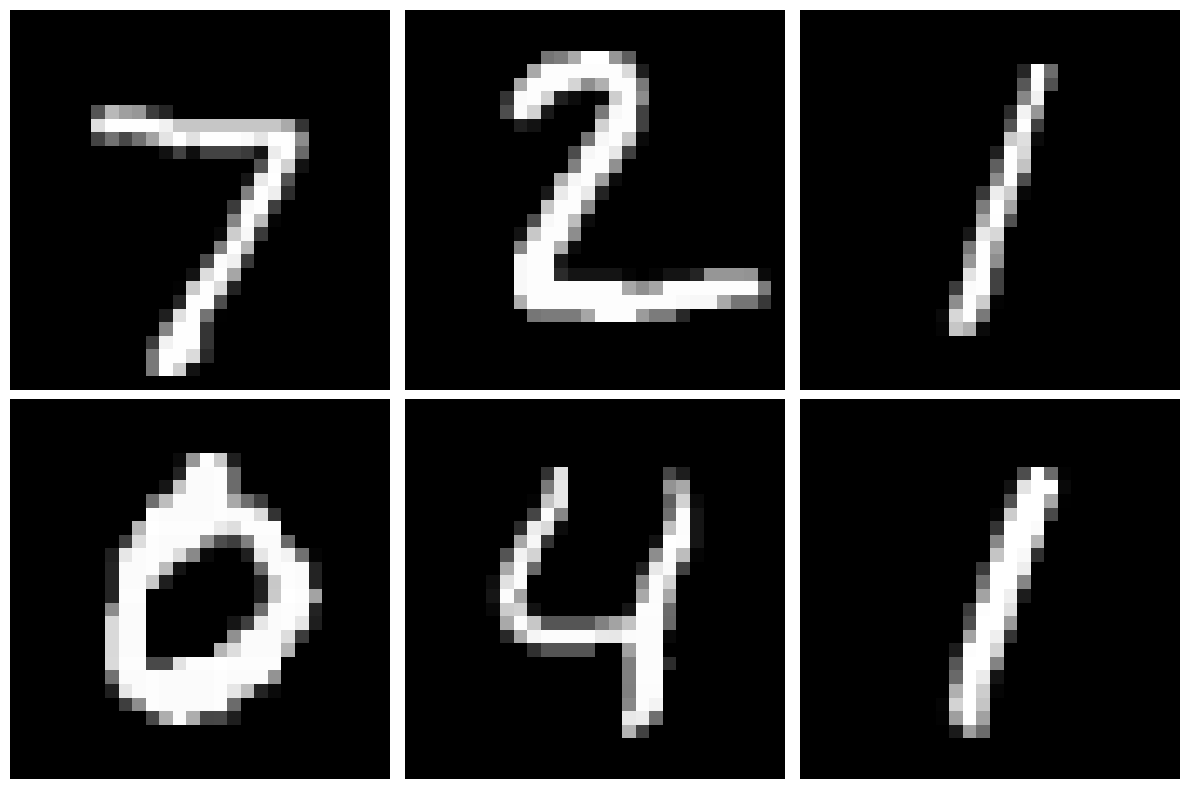

In [325]:
show_images(dataloader=test_loader, num_images=6)

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

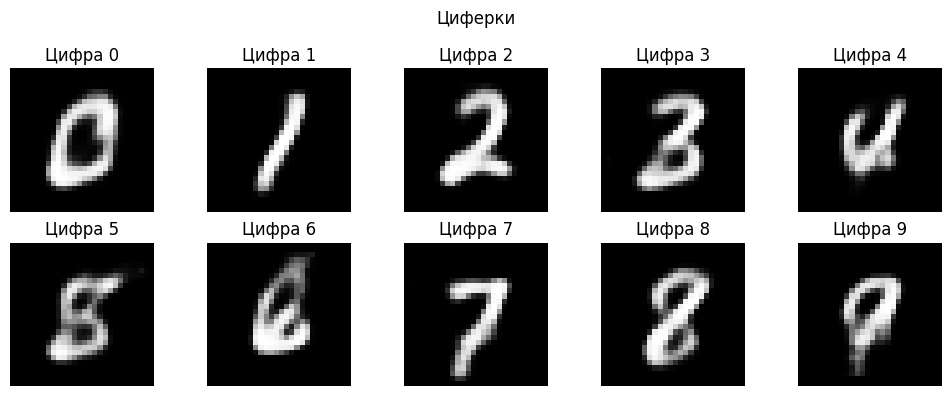

In [327]:
z = torch.randn(1, 20).to(device)

classes = torch.arange(10).to(device) 
class_one_hot = torch.eye(10).to(device)[classes]  

z_repeated = z.repeat(10, 1) 

cvae_model.eval()
with torch.no_grad():
    generated = cvae_model.decode(z_repeated, class_one_hot)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    img = generated[i].cpu().view(28, 28).numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Цифра {i}')
    axes[i].axis('off')

plt.suptitle('Циферки')
plt.tight_layout()
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

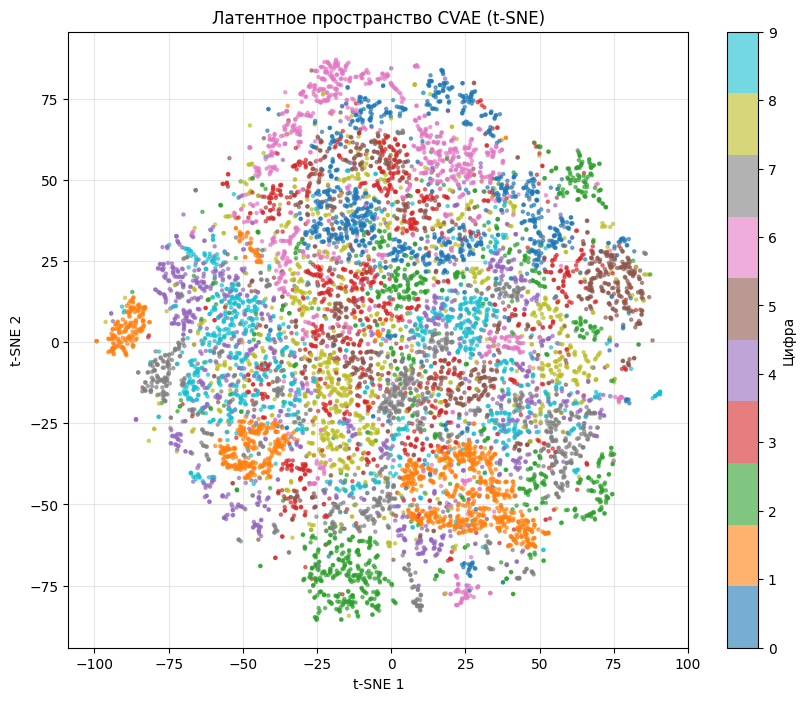

In [329]:
cvae_model.eval()
latent_vectors_cvae = []
labels_cvae = []

with torch.no_grad():
    for batch in test_loader:
        images = batch[0].to(device)
        true_labels = batch[1]

        class_num = torch.eye(10).to(device)[true_labels.to(device)]
        mu, _, _ = cvae_model.encode(images, class_num)
        
        latent_vectors_cvae.append(mu.cpu().numpy())
        labels_cvae.append(true_labels.numpy())

latent_vectors_cvae = np.concatenate(latent_vectors_cvae, axis=0)
labels_cvae = np.concatenate(labels_cvae, axis=0)

tsne = TSNE(n_components=2, random_state=42)
latent_2d_cvae = tsne.fit_transform(latent_vectors_cvae)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d_cvae[:, 0], latent_2d_cvae[:, 1], 
                      c=labels_cvae, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('Латентное пространство CVAE (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

У CVAE латентное пространство выглядит иначе, чем у VAE — кластеры не разделены по классам, точки перемешаны. Это объясняется тем, что CVAE получает информацию о классе отдельно, поэтому латентный вектор кодирует только стиль изображения (наклон, толщину), но не саму цифру. В обычном VAE класс и стиль смешаны, поэтому кластеры разделяются.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [332]:
noise_factor = 0.5
#X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [334]:
all_images = faces_dataset.images.copy() 
all_attrs = faces_dataset.attrs.copy()

noise_factor = 0.5
noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=all_images.shape)
X_noisy = all_images + noise
X_noisy = np.clip(X_noisy, 0., 1.) 
print(f"Форма оригиналов: {all_images.shape}")
print(f"Форма зашумлённых: {X_noisy.shape}")

Форма оригиналов: (13143, 3, 45, 45)
Форма зашумлённых: (13143, 3, 45, 45)


In [335]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(all_images))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_images_noisy = X_noisy[train_idx]
train_images_clean = all_images[train_idx]
train_attrs = all_attrs.iloc[train_idx]

test_images_noisy = X_noisy[test_idx]
test_images_clean = all_images[test_idx]
test_attrs = all_attrs.iloc[test_idx]

In [337]:
train_noisy_tensor = torch.FloatTensor(train_images_noisy)
train_clean_tensor = torch.FloatTensor(train_images_clean)
test_noisy_tensor = torch.FloatTensor(test_images_noisy)
test_clean_tensor = torch.FloatTensor(test_images_clean)

train_dataset = torch.utils.data.TensorDataset(train_noisy_tensor, train_clean_tensor)
test_dataset = torch.utils.data.TensorDataset(test_noisy_tensor, test_clean_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Трейн батчей: {len(train_loader)}, Тест батчей: {len(test_loader)}")

Трейн батчей: 329, Тест батчей: 83


In [348]:
class SimpleDenoiser(nn.Module):
    def __init__(self):
        super(SimpleDenoiser, self).__init__()
        input_size = 3 * 45 * 45
        
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_size),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        x_flat = x.view(batch_size, -1)
        latent = self.encoder(x_flat)
        reconstruction_flat = self.decoder(latent)
        reconstruction = reconstruction_flat.view(batch_size, 3, 45, 45)
        return reconstruction, latent

 30%|███████████▍                          | 9/30 [00:09<00:21,  1.01s/it]

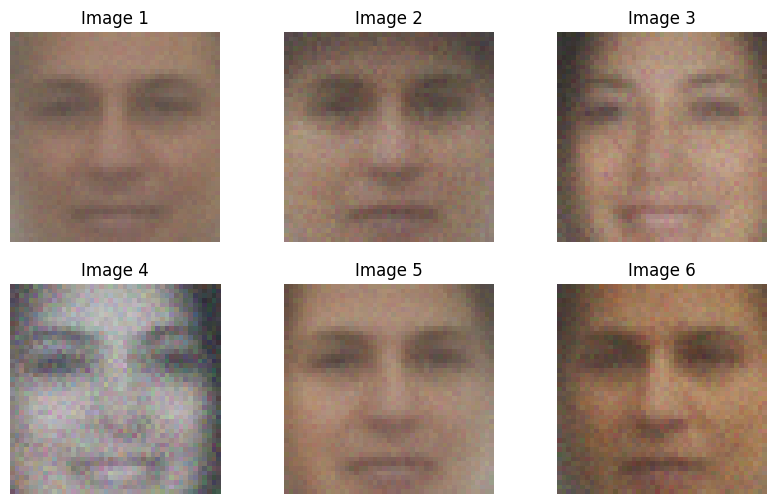

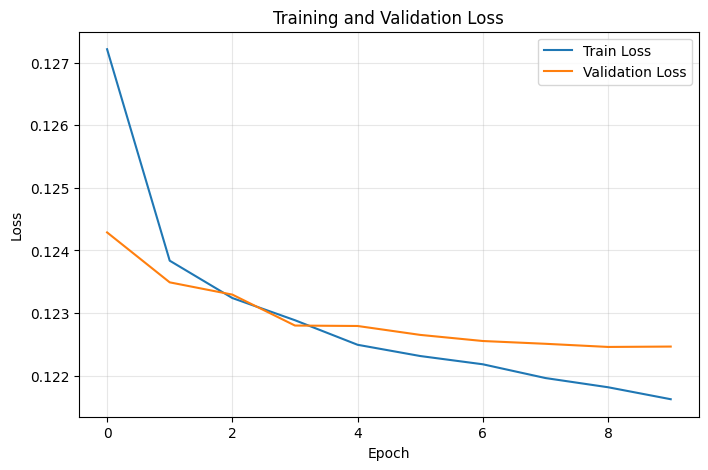

 63%|███████████████████████▍             | 19/30 [00:19<00:10,  1.01it/s]

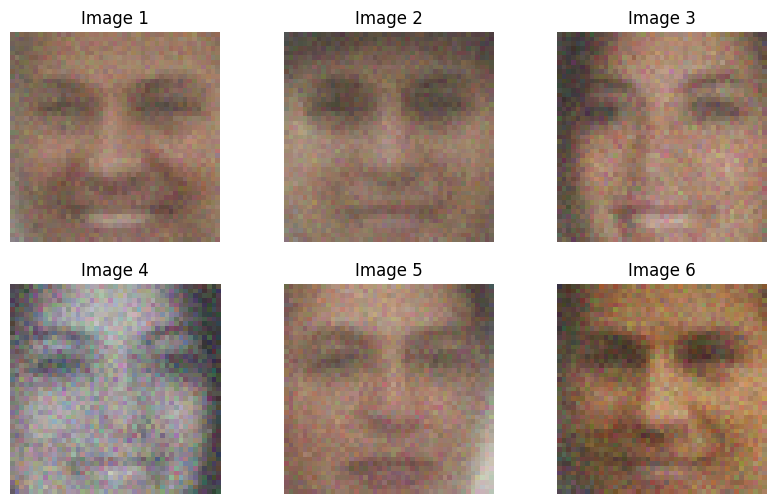

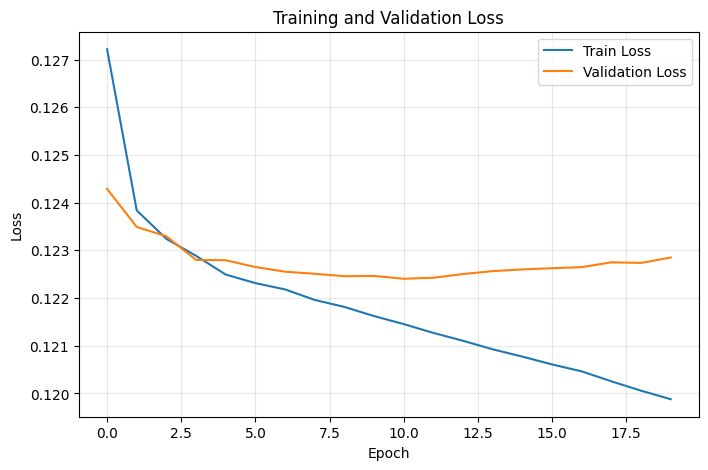

 83%|██████████████████████████████▊      | 25/30 [00:26<00:05,  1.06s/it]


In [349]:
model = SimpleDenoiser()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

trainer = TrainingModel(model, criterion=criterion, optimizer=optimizer, 
                        model_name='SimpleDenoiser')
trainer.train_model(num_epoch=30, patience=15,
                    train_dataloader=train_loader, val_dataloader=test_loader,
                    show_images=True, show_loss=True)

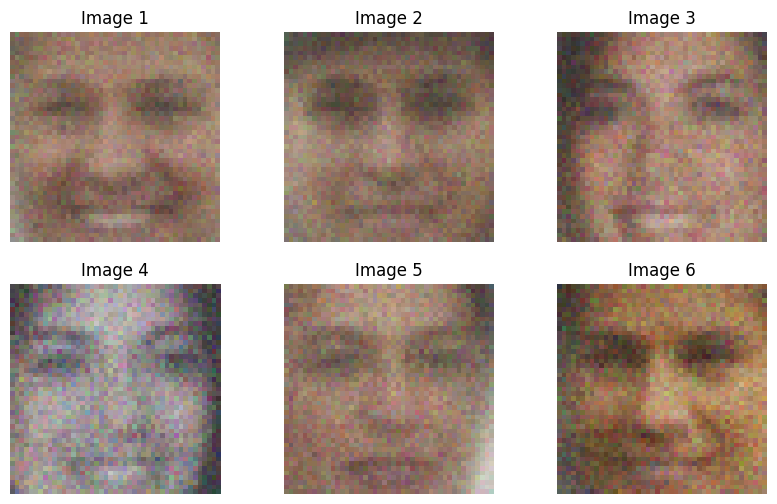

In [350]:
trainer.show_images() #Восстановленные

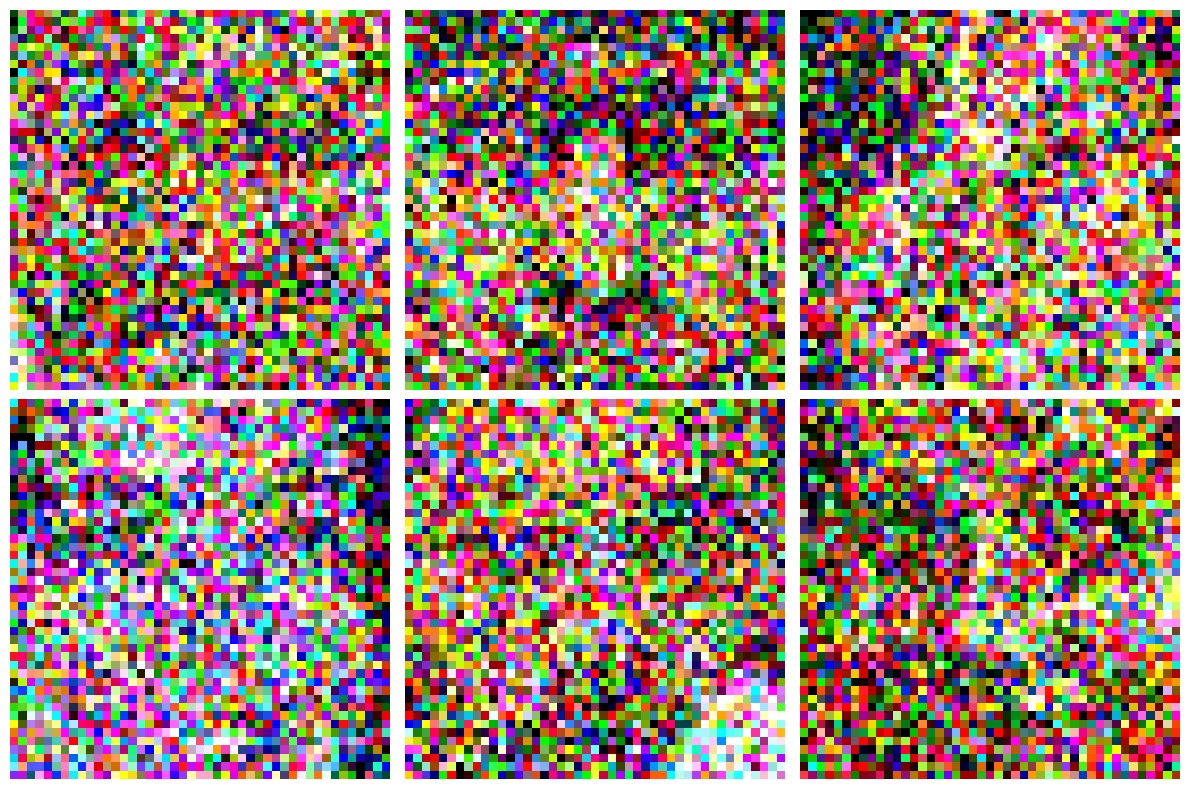

In [351]:
show_images(test_loader, 6) #Что было

In [ ]:
#Учитывая изначальное состояние картинок, автоэнкодер очень хорошо убрал шум

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [359]:
model.eval()
train_latent = []
train_images = []

with torch.no_grad():
    for batch in train_loader:
        noisy_imgs, clean_imgs = batch
        clean_imgs = clean_imgs.to(device)

        _, latent = model(clean_imgs)
        
        train_latent.append(latent.cpu().numpy())
        train_images.append(clean_imgs.cpu().numpy())

train_latent = np.concatenate(train_latent, axis=0)
train_images = np.concatenate(train_images, axis=0)

In [360]:
nn_model = NearestNeighbors(n_neighbors=11, algorithm='auto', metric='euclidean')
nn_model.fit(train_latent)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [361]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей
    model.eval()

    with torch.no_grad():
        img = image.unsqueeze(0).to(device)
        _, code = model(img)
        code = code.cpu().numpy()

    distances, idx = nn_model.kneighbors(code, n_neighbors=n_neighbors)
    
    return distances[0], train_images[idx[0]]

In [369]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances, neighbors = get_similar(image, n_neighbors=11)
    
    plt.figure(figsize=[12, 8])
    
    plt.subplot(3, 4, 1)
    if isinstance(image, torch.Tensor):
        img_show = image.cpu().numpy().transpose(1, 2, 0)
    else:
        img_show = image.transpose(1, 2, 0)
    plt.imshow(img_show)
    plt.title("Искомое лицо")
    plt.axis('off')
    
    for i in range(11):
        plt.subplot(3, 4, i+2)
        neighbor_img = neighbors[i].transpose(1, 2, 0)
        neighbor_img = np.clip(neighbor_img, 0, 1)
        plt.imshow(neighbor_img)
        plt.title(f"Dist={distances[i]:.3f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

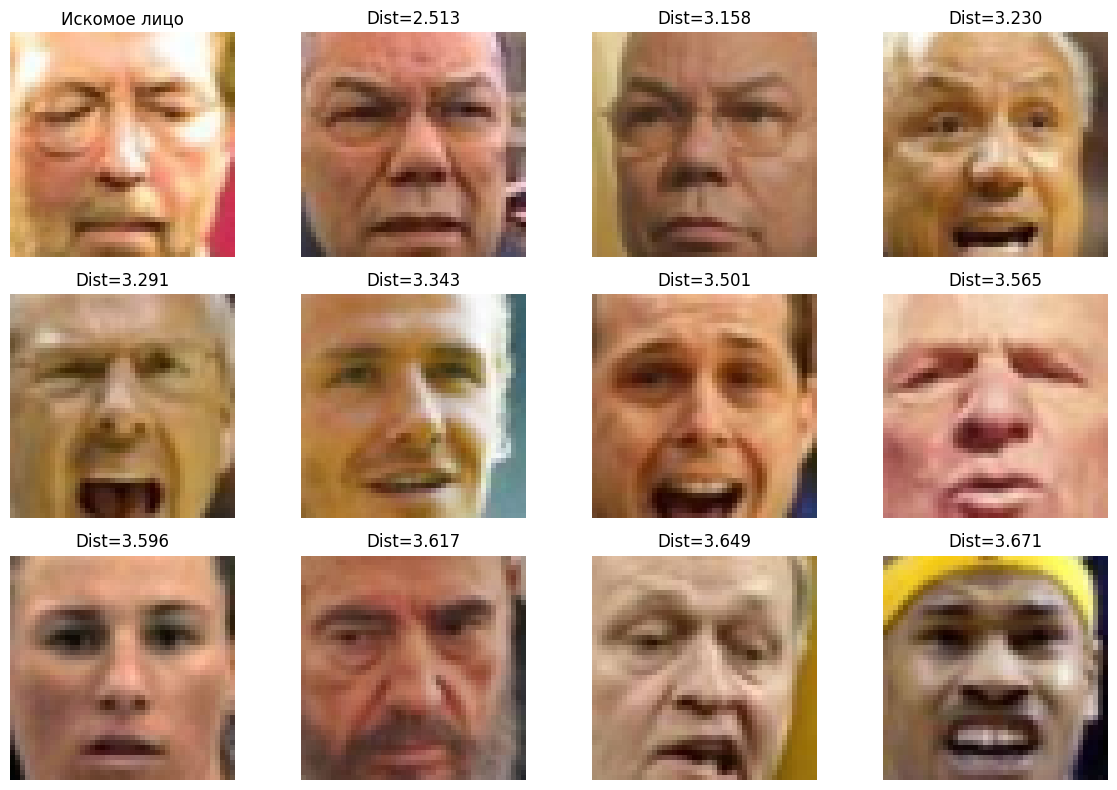

In [370]:
test_noisy, test_clean = next(iter(test_loader))
test_image = test_clean[8]  

show_similar(test_image)